# Improved CNN with Adversarial Training (FGSM Defense)

**Mini Project Upgrade**

This notebook improves robustness by applying adversarial training and a stronger CNN architecture.

In [1]:
# !pip install torch torchvision matplotlib adversarial-robustness-toolbox

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier

In [4]:
transform = transforms.ToTensor()
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=100, shuffle=False)
x_test, y_test = next(iter(testloader))

In [5]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

In [6]:
classifier = PyTorchClassifier(
    model=model,
    clip_values=(0, 1),
    loss=criterion,
    input_shape=(3, 32, 32),
    nb_classes=10
)

In [11]:
fgsm = FastGradientMethod(estimator=classifier, eps=0.5)
model.train()
for epoch in range(3):
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        adv_images = fgsm.generate(x=images.numpy())
        adv_images = torch.from_numpy(adv_images)
        adv_outputs = model(adv_images)
        adv_loss = criterion(adv_outputs, labels)
        total_loss = loss + adv_loss
        total_loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {total_loss.item():.4f}")

Epoch 1, Loss: 3.0137
Epoch 2, Loss: 1.1774
Epoch 3, Loss: 2.2960


In [13]:
x_test_adv = fgsm.generate(x=x_test.numpy())

In [15]:
model.eval()
with torch.no_grad():
    clean_preds = model(x_test).argmax(1)
    adv_preds = model(torch.from_numpy(x_test_adv)).argmax(1)
clean_acc = (clean_preds == y_test).float().mean().item()
adv_acc = (adv_preds == y_test).float().mean().item()
print(f"Clean Accuracy: {clean_acc:.2%}")
print(f"Adversarial Accuracy (FGSM): {adv_acc:.2%}")
print(f"Robustness Score: {(adv_acc / clean_acc) * 100:.2f}%")

Clean Accuracy: 72.00%
Adversarial Accuracy (FGSM): 64.00%
Robustness Score: 88.89%


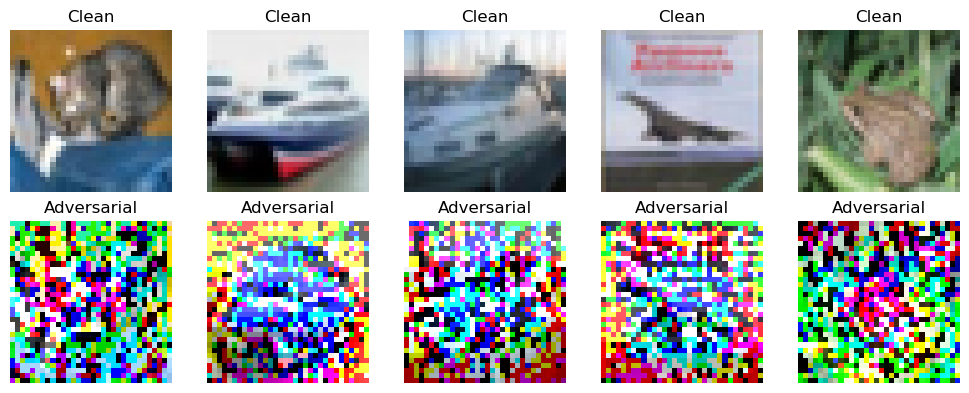

In [16]:
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].permute(1, 2, 0))
    plt.title("Clean")
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(np.transpose(x_test_adv[i], (1, 2, 0)))
    plt.title("Adversarial")
    plt.axis('off')
plt.tight_layout()
plt.show()